This notebook concentrates on algorithmic audio processing; see also ./tf.ipynb

# imports

In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/Users/andreassteiner/git/rizhom/env/bin/python


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile
import scipy.signal

import pyaudio
import aubio
# import bob.ap

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, audio, features, hotplug, settings, signals as S, util

Signal = S.Signal

hp = hotplug.HotPlug()

In [5]:
# Using interface `0` by default.
p = pyaudio.PyAudio()
for i in range(p.get_device_count()):#list all available audio devices
    dev = p.get_device_info_by_index(i)
    print((i, dev['name'], dev['maxInputChannels']))

(0, 'Built-in Microphone', 2)
(1, 'Built-in Output', 0)
(2, 'iShowU Audio Capture', 2)
(3, 'Multi-Output Device', 0)


# record

In [7]:
audio_interface = audio.AudioInterface(input_channels=1, output_channels=1)
settings.to_string()

'rate=16000 buf_secs=0.064s (1024) hop_secs=0.032s (512) '

* recording
* done recording


(111616, 6.976)

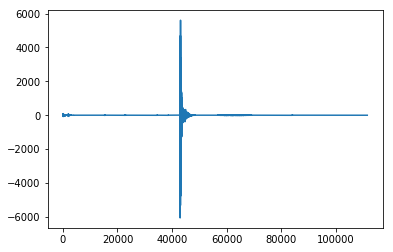

In [11]:
# record ...
data = audio_interface.record(secs=7)
plt.plot(data)
len(data), len(data)/settings.rate

In [94]:
# store recording...
scipy.io.wavfile.write('../recordings/t_a_5.wav', rate, data)
# !ls -lh ../recordings/*

-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 21:46 ../recordings/a_welle.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:11 ../recordings/m_g_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:12 ../recordings/m_g_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_3.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:13 ../recordings/o_a_4.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 11 00:14 ../recordings/o_a_5.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:56 ../recordings/o_g_1.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_2.wav
-rw-rw-r-- 1 gabriel gabriel 219K Apr 10 23:57 ../recordings/o_g_3.wav
-rw-

# abase, transform

In [8]:
ab = abase.ABase(load_wav=True)
ab.load('logmel')
ab.load('mfccs')

loaded 35/35 (100.00%)
loaded 35/35 (100.00%)


Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/logmel.pickle : 3.71M (0.0s)


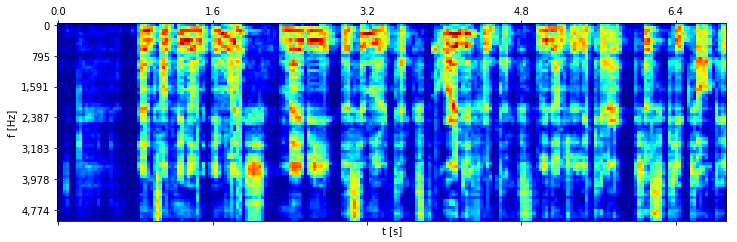

In [361]:
ab.transform('logmel', lambda row: features.log_mel_spectrogram(row['wav']))
util.plot_logmel(ab.df.loc[ab.sample(), 'logmel'])

loaded 35/35 (100.00%)
Updated 35/35 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/mfccs.pickle : 0.70M (0.0s)


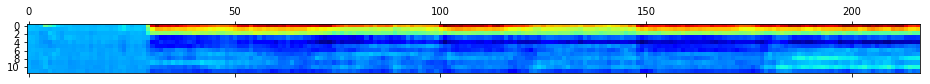

In [362]:
ab.load('logmel')
ab.transform('mfccs', lambda row: features.mfccs(data=None, logmel=row['logmel']))
plt.matshow(ab.df.loc[ab.sample(), 'mfccs'].T, cmap='jet')

# analyze

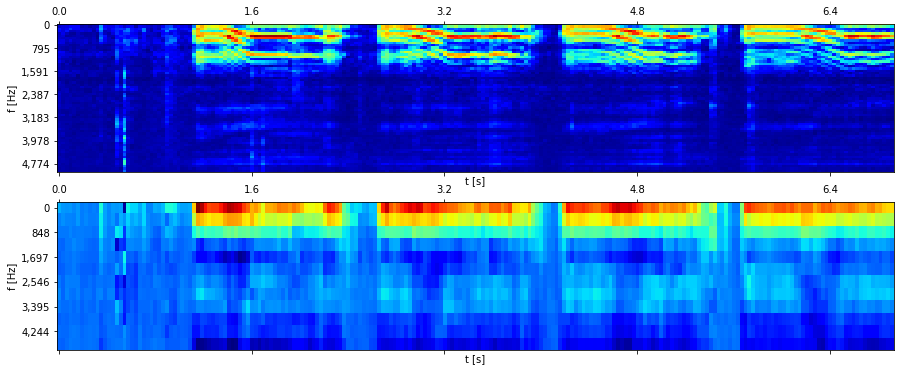

In [9]:
plt.figure(figsize=(15, 6))
util.plot_logmel(ab.df.loc['o_p_4', 'logmel'], ax=plt.subplot(211), aspect='auto')
util.plot_logmel(ab.df.loc['o_p_4', 'mfccs'], ax=plt.subplot(212), aspect='auto')

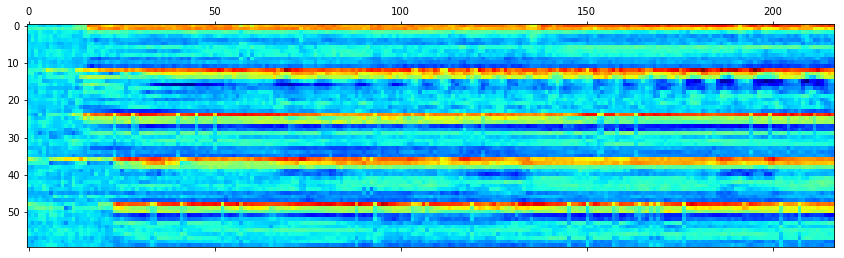

In [292]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "o"').sample(5)].mfccs.values).T, cmap='jet')

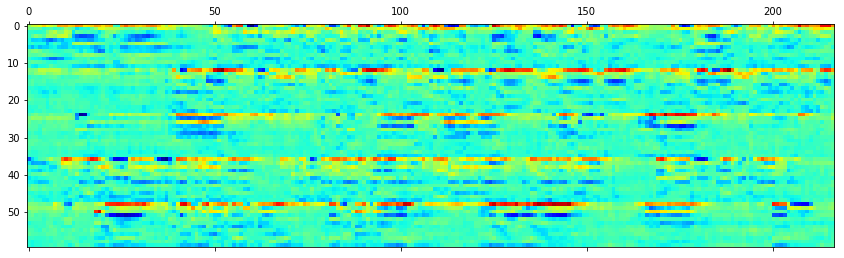

In [293]:
plt.matshow(np.hstack(ab.df.loc[ab.query('what == "t"').sample(5)].mfccs.values).T, cmap='jet')

## signals

incubating ... to be moved to "signal" module

### plot utils

In [311]:
def plot_signals(row, signals1, signals2=(), cols='krgbmcy', hzmax=None):
    """Displays logmel and values derived from signals1,2 on twin axes."""
    plt.figure(figsize=(15, 6))
    util.plot_logmel(row.logmel, ax=plt.subplot(211), aspect='auto', hzmax=hzmax)
    i = 0
    signals = list(signals1) + list(signals2)
    values = [[] for _ in signals]
    for buf in util.Streamer(row.wav):
        feats = features.wav2features(buf)
        for i, signal in enumerate(signals):
            values[i].append(signal(feats))
    axs = [plt.subplot(212)]
    axs.append(axs[0].twinx())
    for i, signal in enumerate(signals):
        axs[i >= len(signals1)].plot(
            values[i], cols[i % len(cols)] + ('-' if i < len(signals1) else '--'))
    return values

def plot_dfs(df_by_col, signals):
    """Plots signal in separate graphs from dataframe rows with different colors."""
    assert len(signals) > 1
    _, axs = plt.subplots(len(signals), 1, figsize=(15, 10))
    for col, df in df_by_col.items():
        for _, row in df.iterrows():
            values = [[] for _ in signals]
            for buf in util.Streamer(row.wav):
                feats = features.wav2features(buf)
                for i, signal in enumerate(signals):
                    values[i].append(signal(feats))
            for i, value in enumerate(values):
                axs[i].plot(value, col)

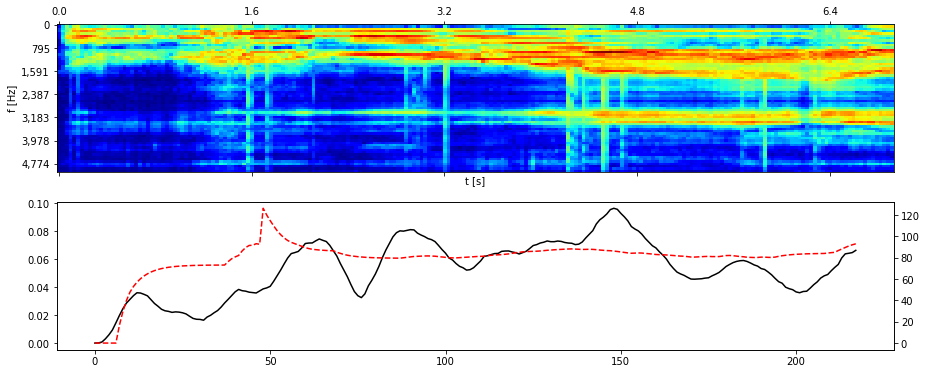

In [312]:
vs = plot_signals(ab.data.o_a_3, [
    # 0..1 axis
    S.Louder(n=10) | S.F(mult=10),
#     ThresholdedFrequencies(hz=2000, threshold=-1, bins=3)
], [
    # freq axis
    S.Pitcher() | S.Limiter(maxv=300) | S.Exponential(alpha=0.8),
#     WeightedAverage(),
])

### utility signals

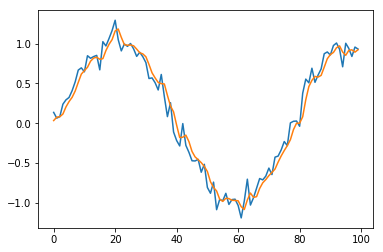

In [315]:
x = np.sin(np.linspace(0, 8, 100)) + np.random.normal(scale=0.1, size=100)
plt.plot(x)
h = S.Hamming(5)
plt.plot([h(_) for _ in x])

### base freq

Follow the lowest peak above threshold.

Does not work very well because : with harmonics, the max value is both
sensitive to the width of the band and to the number of harmonics; will be
much worse with noise...

In [259]:
ts = [3.4, 3.6, 3.8, 4.0]
row = ab.data.o_p_3

# base freq: not as clear ...
ts = [2.9, 3.0, 3.1, 3.2, 3.3]
row = ab.data.w_a_1

# base freq: more harmonics; goes down with peaks=5, but up with peaks=3
ts = [3.0, 3.1, 3.2, 3.3, 3.4, 3.5]
row = ab.data.o_g_2

In [206]:
row.play()

In [260]:
logmel256 = features.log_mel_spectrogram(row.wav, num_mel_bins=256, window_length_secs=0.256)
logmel = row.logmel

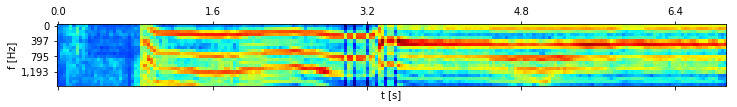

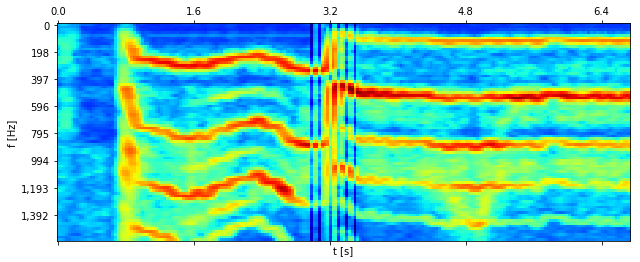

In [261]:
def plot_with(logmel, ts, hzmax=1600, ax=None):
    xs = [int(t * settings.rate / settings.hop_size) for t in ts]
    logmel_mod = logmel.copy()
    for x in xs:
        logmel_mod[x, :] -= 2
    util.plot_logmel(logmel_mod, hzmax=hzmax, ax=ax)

plot_with(logmel, ts)
plot_with(logmel256, ts)

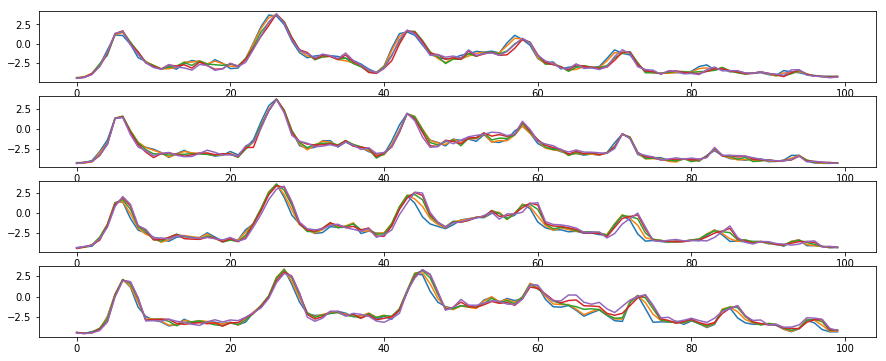

In [207]:
_, axs = plt.subplots(len(xs), 1, figsize=(15, 6))
for i, x in enumerate(xs):
    for dx in range(5):
        axs[i].plot(logmel256[x + dx, :100])

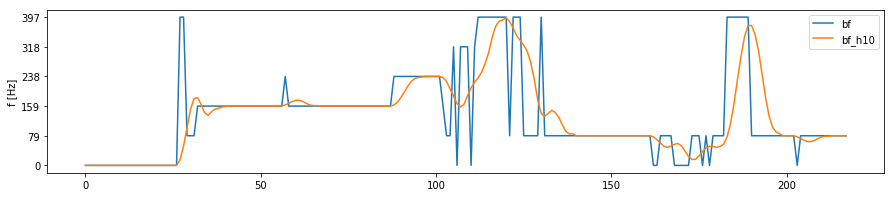

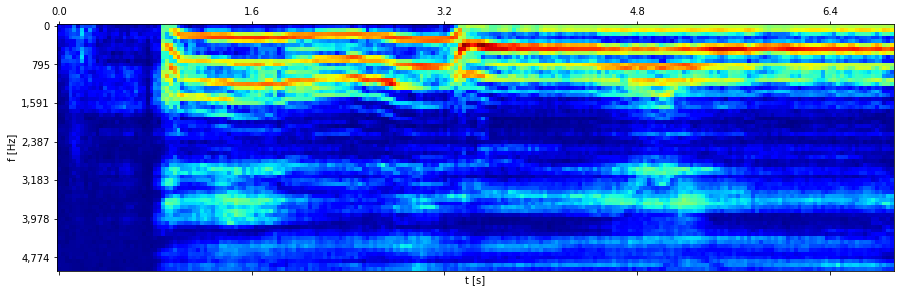

In [274]:
class BaseMax(Signal):
    def __init__(self, threshold, fmax=0, peaks=5, which='logmel'):
        self.threshold = threshold
        self.peaks = peaks
        self.which = which
        self.fmax = fmax

    def __call__(self, feats):
        logmel = getattr(feats, self.which)
        fmax = self.fmax if self.fmax else len(logmel)
        logmel = logmel[:fmax]
        logmel *= logmel > self.threshold
        if logmel.sum() == 0:
            return 0
        return logmel[:fmax].argsort()[-self.peaks:].min()


hzmax = 0
plt.figure(figsize=(15, 3))
for name, values in util.get_signals(row.wav, {
    'bf': BaseFreq(-0.5),
    'bf_h10': BaseFreq(-0.5) | S.Hamming(10),
#     'bf2': BaseFreq(-0.5, which='logmel2') | S.F(mult=1/4),
#     'bf2_h10': BaseFreq(-0.5, which='logmel2') | S.Hamming(10) | S.F(mult=1/4),
}).items():
    plt.plot(values, label=name)
plt.gca().set_yticklabels([
    '{:,}'.format(int(f * settings.f2hz))
    for f in plt.gca().get_yticks()
])
plt.gca().set_ylabel('f [Hz]')
plt.legend()

plt.figure(figsize=(15, 7))
plot_with(logmel, [], ax=plt.gca(), hzmax=hzmax);

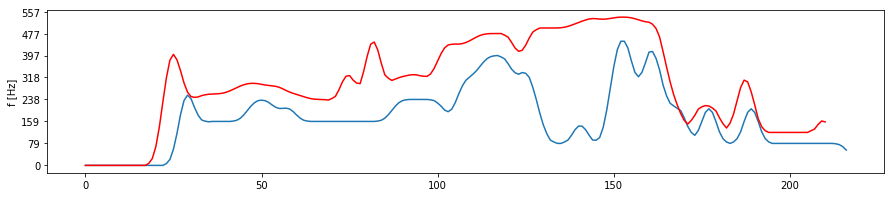

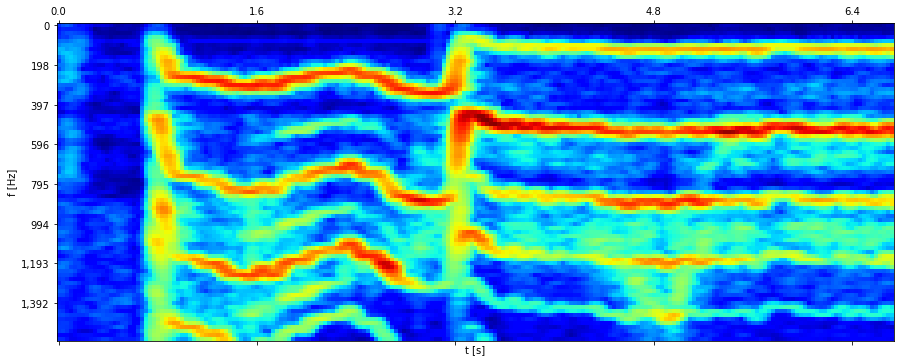

In [213]:
def smooth(vs, n=10):
    w = np.hamming(n)
#     w = np.ones(n)
    return numpy.convolve(vs, w, mode='same')/w.sum()

def get_base_freq(logmel, threshold=-0.5, peaks=4):
    vs = []
    for t, fs in enumerate(logmel):
        m = fs.argsort()[-peaks:].min()
        vs.append(m * (fs[m] > threshold))
    return np.array(vs)

plt.figure(figsize=(15, 3))
plt.plot(smooth(get_base_freq(logmel[:, :])))
plt.plot(smooth(get_base_freq(logmel256[:, :]))/4, 'r')

plt.figure(figsize=(15, 7))
plot_with(logmel256, [], ax=plt.gca())
None

### base follower

### freq bands

In [314]:
row = ab.data.w_a_1

In [ ]:
row.play()

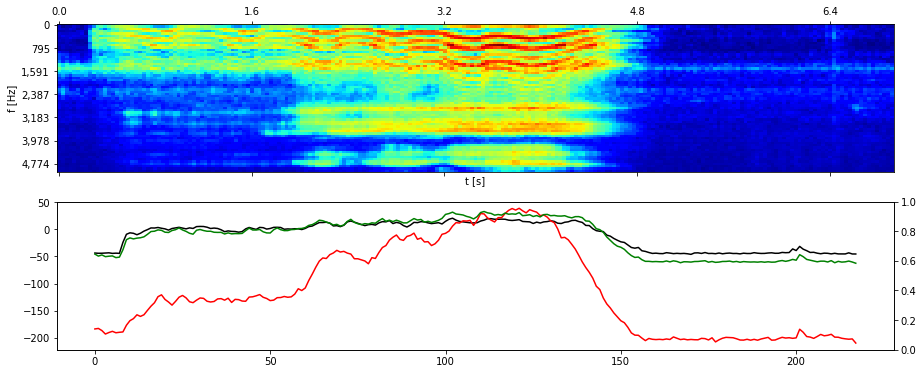

In [313]:
plot_signals(row, [
    S.FreqBand(hzmin=0, hzmax=800, hzslope=50),
    S.FreqBand(hzmin=800, hzmax=1e10, hzslope=50),
    S.FreqBand(hzmin=400, hzmax=1600, hzslope=50),
], [], hzmax=None);

### freq breadth

In [316]:
row = ab.data.o_a_3

In [335]:
row.play()

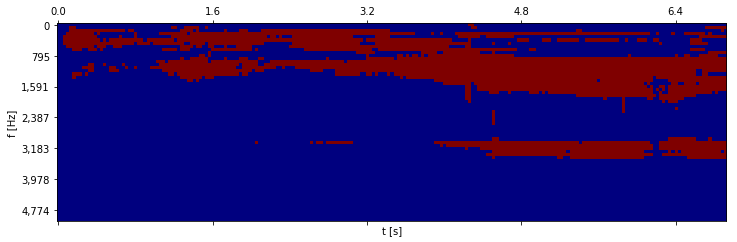

In [334]:
util.plot_logmel(row.logmel > -1)

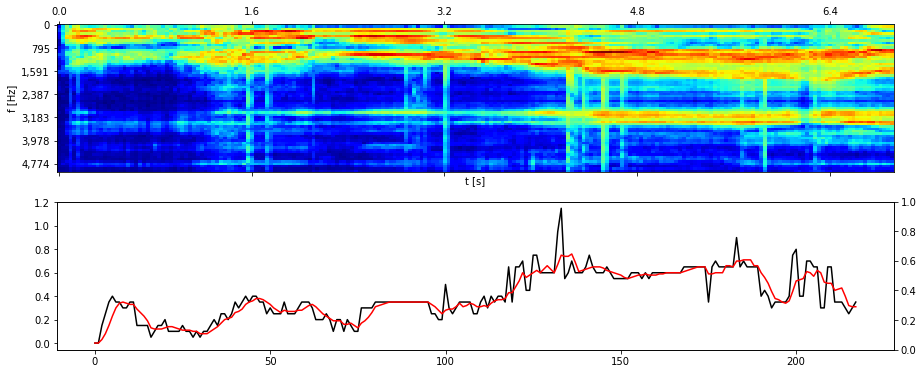

In [329]:
plot_signals(row, [
    S.FreqBreadth(-1) | S.F(mult=1/20),
    S.FreqBreadth(-1) | S.F(mult=1/20) | S.Clip(0, 1) | S.MovingAverage(5),
], [], hzmax=None);

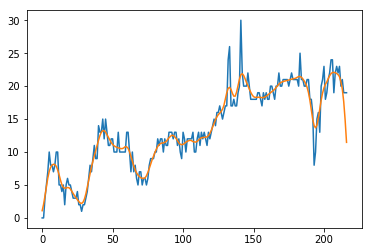

In [462]:
x = (ab.data.o_a_3.logmel > -1).sum(axis=1)
plt.plot(x)
w = np.hamming(11)
plt.plot(numpy.convolve(x, w, mode='same')/w.sum())

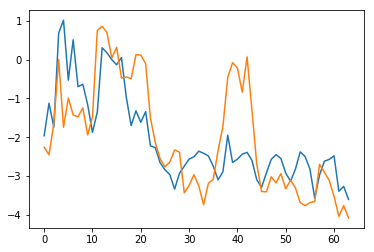

In [443]:
plt.plot(ab.data.o_a_3.logmel[int(1.6/settings.hop_secs), :])
plt.plot(ab.data.o_a_3.logmel[int(4.8/settings.hop_secs), :])

## plot

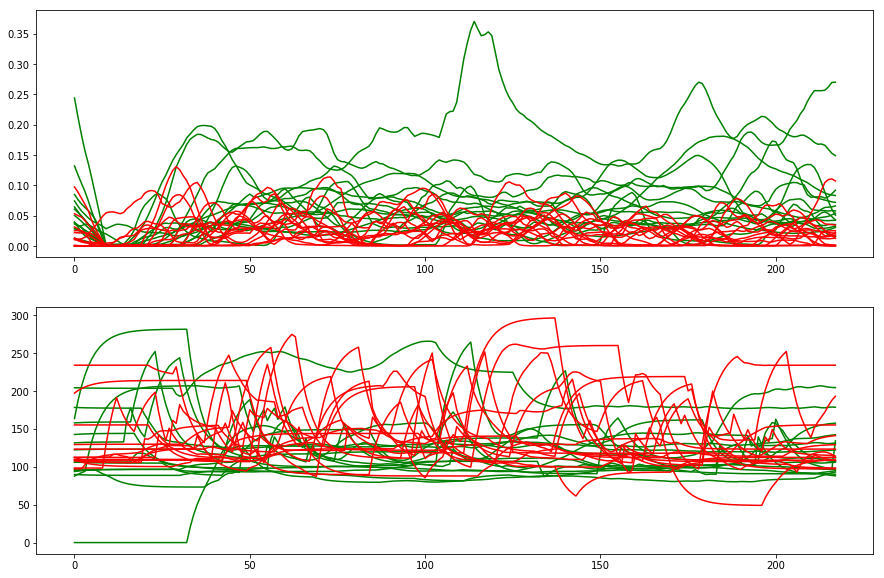

In [17]:
plot_dfs(dict(
    g=ab.df.query('what == "o"'),
    r=ab.df.query('what == "t"'),
), (
    S.Louder(n=10) | S.F(mult=10),
    S.Pitcher() | S.Limiter(maxv=300) | S.Exponential(alpha=0.8),
))

# effects

'o_p_3'

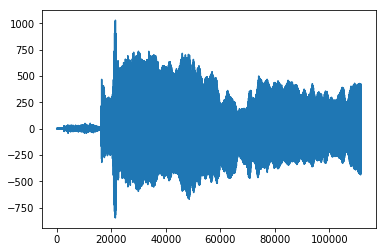

In [132]:
name = ab.sample()
wav = ab.df.loc[name].wav
plt.plot(wav)
name

## echo

In [273]:
class EchoDelayEffect:
    def __init__(self, delay_s=0.2, coeff=0.7):
        """Use coeff=0 for pure delay."""
        self.delay_s = delay_s
        self.delay_n = int(delay_s / settings.hop_secs)
        self.coeff = coeff
        self.bufs = np.zeros((self.delay_n, settings.hop_size))
        self.i = 0

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[:settings.hop_size]
        n = self.bufs.shape[0]
        delayed = self.bufs[self.i % n].copy()
        if self.coeff > 0:
            self.bufs[self.i % n] = buf + delayed * self.coeff
            ret = self.bufs[self.i % n]
        else:
            self.bufs[self.i % n] = buf
            ret = delayed
        self.i += 1
        return ret


# does NOT work (clicking)
class LowpassEffect:
    def __init__(self, cutoff=880, numtaps=40):
        self.h = scipy.signal.firwin(numtaps=numtaps, cutoff=cutoff,
                                     nyq=settings.rate/2)

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = scipy.signal.lfilter(self.h, 1.0, buf)
        d = int((settings.buf_size - settings.hop_size)/2)
        return buf[d: settings.hop_size]

audio_interface = audio.AudioInterface(output_channels = 1)
effect = EchoDelayEffect()
# effect = EchoDelayEffect(delay_s=2, coeff=0)
# effect = LowpassEffect()
secs = 0
wav = ab.df.loc['o_p_2', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## stereo

In [276]:
class PanSinusEffect:
    def __init__(self, period_s=4):
        self.period_s = period_s
        self.i = 0

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        v = (1 + np.sin(self.i * settings.hop_secs / self.period_s * 2 * np.pi)) / 2
        self.i += 1
        left = buf * v
        right = buf * (1 - v)
        return np.vstack([left, right]).reshape(-1, order='F')

class RightDelayEffect:
    def __init__(self, delay_s=2):
        self.delay_s = delay_s
        self.delay_effect = EchoDelayEffect(delay_s=delay_s, coeff=0)

    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        left = buf[: settings.hop_size]
        right = self.delay_effect(buf)
        return np.vstack([left, right]).reshape(-1, order='F')

class MonoToStereoEffect:
    def __call__(self, buf):
        assert buf.dtype == np.float32
        assert len(buf) == settings.buf_size
        buf = buf[: settings.hop_size]
        return np.vstack([buf, buf]).reshape(-1, order='F')

audio_interface = audio.AudioInterface(input=False, output=True, output_channels=2)
effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['t_g_1', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## compose

In [275]:
audio_interface = audio.AudioInterface(output_channels=2)
# effect = PanSinusEffect()
effect = RightDelayEffect()
secs = 0
wav = ab.df.loc['o_p_5', 'wav']
for i, data in enumerate(util.Streamer(wav)):
    if secs and i > secs / settings.hop_secs:
        break
    data = util.int16_to_float(data)
    data = effect(data)
    data = util.float_to_int16(data)
    audio_interface.play(data)

## frequency filters

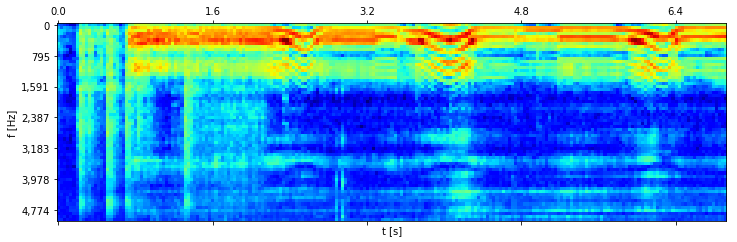

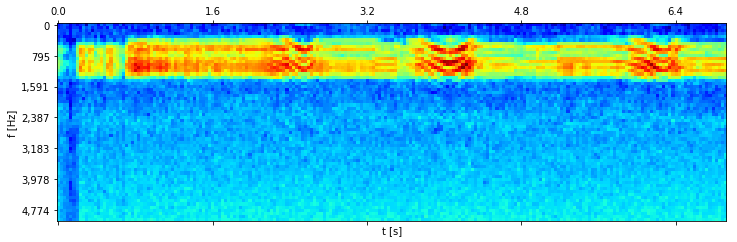

In [197]:
def butter_highpass(cutoff, order=5):
    nyq = 0.5 * settings.rate
    normal_cutoff = cutoff / nyq
    b, a = scipy.signal.butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_bandpass(lowcut, highcut, order=5):
    nyq = 0.5 * settings.rate
    low = lowcut / nyq
    high = highcut / nyq
    b, a = scipy.signal.butter(order, [low, high], btype='band', analog=False)
    return b, a

def bandpass_kaiser(ntaps, lowcut, highcut, fs, width):
    nyq = 0.5 * fs
    atten = kaiser_atten(ntaps, width / nyq)
    beta = kaiser_beta(atten)
    taps = firwin(ntaps, [lowcut, highcut], nyq=nyq, pass_zero=False,
                  window=('kaiser', beta), scale=False)
    return taps

h = scipy.signal.firwin(numtaps=100, cutoff=100, nyq=settings.rate/2)
b, a = butter_highpass(cutoff=800)
b, a = butter_bandpass(lowcut=400, highcut=800)
data = wav
data = util.int16_to_float(data)
# data = scipy.signal.lfilter(h, 1.0, data)
data = scipy.signal.filtfilt(b, a, data)
data = util.float_to_int16(data)

util.plot_logmel(features.log_mel_spectrogram(wav))
util.plot_logmel(features.log_mel_spectrogram(data))